In [1]:
from spin_lattices import KagomeLattice, SpinLattice, ChainLattice, FactorLattice
from sympy.combinatorics import Permutation, PermutationGroup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from igraph import Graph
import igraph
import itertools
from heisenberg_hamiltonians import HeisenbergJ1J2

2023-06-28 18:48:43.266 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-06-28 18:48:43.271 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-06-28 18:48:43.320 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


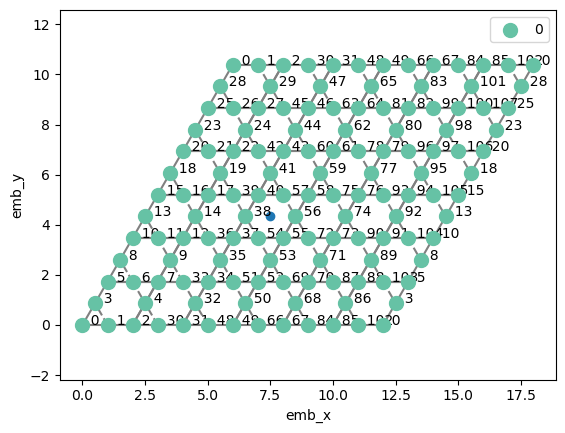

In [2]:
lat = KagomeLattice(6, 6)
u, v = lat.lattice_basis.T
lat.plot()
hexagonal_center = lat.sites_df[['emb_x', 'emb_y']].mean().to_numpy() - u - v
plt.plot(*hexagonal_center, 'o')

In [3]:
df = lat.sites_df.assign(
    distance_to_center=lambda df: df[["emb_x", "emb_y"]]
    .sub(df[["emb_x", "emb_y"]].mean(axis=0), axis=1)
    .pow(2)
    .sum(axis=1)
    .pow(0.5)
).sort_values("distance_to_center").reset_index(drop=True)

In [4]:
df.head(50)

,num,ix,iy,is_canonical,emb_x,emb_y,distance_to_center
0,58,6,6,True,9.0,5.196152,8.881784e-16
1,56,6,5,True,8.5,4.330127,1.000000e+00
2,75,7,6,True,10.0,5.196152,1.000000e+00
3,57,5,6,True,8.0,5.196152,1.000000e+00
4,59,6,7,True,9.5,6.062178,1.000000e+00
5,72,7,4,True,9.0,3.464102,1.732051e+00
6,41,4,7,True,7.5,6.062178,1.732051e+00
7,74,8,5,True,10.5,4.330127,1.732051e+00
8,60,5,8,True,9.0,6.928203,1.732051e+00
9,40,4,6,True,7.0,5.196152,2.000000e+00


In [5]:
lat.sites_df

,num,ix,iy,is_canonical,emb_x,emb_y
0,0,0,0,True,0.0,0.000000
1,1,1,0,True,1.0,0.000000
2,2,2,0,True,2.0,0.000000
3,3,0,1,True,0.5,0.866025
4,4,2,1,True,2.5,0.866025
...,...,...,...,...,...,...
128,107,11,10,True,16.0,8.660254
129,25,12,10,False,17.0,8.660254
130,28,12,11,False,17.5,9.526279
131,102,11,12,False,17.0,10.392305


In [6]:
df.assign(
    selected=lambda df: df["distance_to_center"] < df["distance_to_center"].iloc[45] - 1e-5
).query("num == 16")

,num,ix,iy,is_canonical,emb_x,emb_y,distance_to_center,selected
63,16,1,6,True,4.0,5.196152,5.0,False


In [7]:
lat.edges_to_kind

{(0, 1): 1,
 (1, 2): 1,
 (0, 3): 1,
 (1, 3): 2,
 (3, 5): 1,
 (5, 6): 1,
 (6, 4): 2,
 (6, 7): 1,
 (4, 7): 1,
 (2, 4): 1,
 (5, 8): 1,
 (6, 8): 2,
 (8, 10): 1,
 (10, 11): 1,
 (11, 9): 2,
 (11, 12): 1,
 (9, 12): 1,
 (7, 9): 1,
 (10, 13): 1,
 (11, 13): 2,
 (13, 15): 1,
 (15, 16): 1,
 (16, 14): 2,
 (16, 17): 1,
 (14, 17): 1,
 (12, 14): 1,
 (15, 18): 1,
 (16, 18): 2,
 (18, 20): 1,
 (20, 21): 1,
 (21, 19): 2,
 (21, 22): 1,
 (19, 22): 1,
 (17, 19): 1,
 (20, 23): 1,
 (21, 23): 2,
 (23, 25): 1,
 (25, 26): 1,
 (26, 24): 2,
 (26, 27): 1,
 (24, 27): 1,
 (22, 24): 1,
 (25, 28): 1,
 (26, 28): 2,
 (28, 0): 1,
 (1, 29): 2,
 (29, 2): 1,
 (27, 29): 1,
 (2, 30): 1,
 (30, 31): 1,
 (30, 4): 2,
 (7, 33): 1,
 (33, 32): 2,
 (33, 34): 1,
 (32, 34): 1,
 (31, 32): 1,
 (33, 9): 2,
 (12, 36): 1,
 (36, 35): 2,
 (36, 37): 1,
 (35, 37): 1,
 (34, 35): 1,
 (36, 14): 2,
 (17, 39): 1,
 (39, 38): 2,
 (39, 40): 1,
 (38, 40): 1,
 (37, 38): 1,
 (39, 19): 2,
 (22, 42): 1,
 (42, 41): 2,
 (42, 43): 1,
 (41, 43): 1,
 (40, 41): 1,


In [8]:
def get_adjacent_sites(site: int, edges_to_kind: dict[tuple[int, int], int]) -> list[int]:
    adjacent_sites = []
    for edge in edges_to_kind:
        if site == edge[0]:
            adjacent_sites.append(edge[1])
        elif site == edge[1]:
            adjacent_sites.append(edge[0])
    return adjacent_sites

In [9]:
def dilatate(lattice, sites_mask, n=1):
    assert n >= 0
    if n == 0:
        return sites_mask
    dilatated_mask = sites_mask.copy()
    for site_num in range(lattice.number_spins):
        if sites_mask[get_adjacent_sites(site_num, lattice.edges_to_kind)].any():
            dilatated_mask[site_num] = 1
    return dilatate(lattice, dilatated_mask, n=n-1)

In [10]:
hexagon_nums = df.head(6)["num"].to_numpy()
hexagon_mask = np.isin(np.arange(lat.number_spins), hexagon_nums)

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

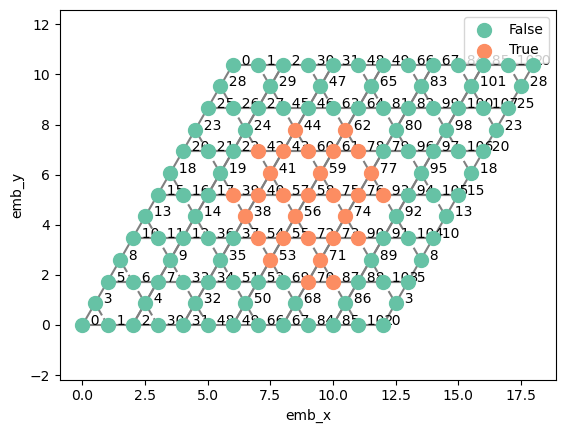

In [11]:
lat.plot(spins=dilatate(lat, hexagon_mask, 2))

In [12]:
lat.as_igraph().get_adjlist()[0]

[1, 3, 28, 102]

In [13]:
from sympy.combinatorics import Permutation, PermutationGroup
from igraph import Graph
from sympy.combinatorics import Permutation, PermutationGroup


def do_images_intersect(
    domain: list[int], group_elements: list[Permutation], verbose=False
) -> bool:
    # For each element in the fundamental_domain
    for a in domain:
        # Apply each group element
        for g in group_elements:
            ga = g(a)
            # If the result is in the fundamental_domain and different from a, return False
            if ga in domain and ga != a:
                if verbose:
                    print(f"Found intersection between {a} and {ga}")
                    print(f"Group element: {g.array_form}")
                return True
    return False


def factor_lattice(
    graph: Graph, group_elements: list[Permutation], fundamental_domain: list[int]
) -> Graph:
    assert not do_images_intersect(fundamental_domain, group_elements)
    # Create an empty graph with vertices corresponding to the fundamental_domain
    factor_graph = Graph()
    factor_graph.add_vertices(map(str, fundamental_domain))

    # For each pair of vertices a and b in fundamental_domain
    for a in fundamental_domain:
        for b in fundamental_domain:
            if a == b:
                continue
            #           print(f"Considering vertices {a} and {b}")
            # If there exists a permutation g in group such that a and g(b) are connected by an edge in the original graph
            for g in [Permutation([[max(fundamental_domain)]])] +  group_elements:
                gb = g(b)
                #              print(f"Considering vertex {gb=}")
                if graph.are_connected(a, gb):
                    #                    print("There is a connection!")
                    # Check if the edge already exists in the factor_graph
                    if factor_graph.get_eid(str(a), str(b), error=False) == -1:
                        #                     print("Adding edge to factor graph")
                        # If not, then add an edge between a and b in factor_graph, preserving the edge attribute 'kind' from the original graph
                        edge_id = graph.get_eid(a, gb)
                        kind = graph.es[edge_id]["kind"]
                        factor_graph.add_edge(str(a), str(b), kind=kind)
    #                else:
    #                    print("Edge already exists, skipping")

    return factor_graph


### END FROM

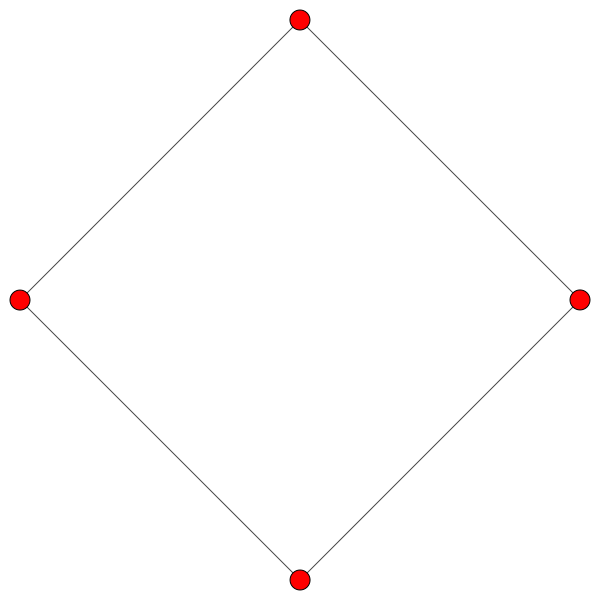

In [14]:
lat = ChainLattice(16)
tx = Permutation(lat.get_translation('x'))
fundamental_domain = [0, 1, 2, 3]
igraph.plot(factor_lattice(lat.as_igraph(), [tx ** 4, tx ** (-4)], fundamental_domain))

In [15]:
def is_inside_starry_region(site, center, starry_region):
    # get polar coordinates of site - center:
    r, phi = np.linalg.norm(site - center), np.arctan2(site[1] - center[1], site[0] - center[0])
    return r <= starry_region(phi)

def is_inside_starry_region_row(row, center, starry_region):
    return is_inside_starry_region(row[['emb_x', 'emb_y']].to_numpy(), center, starry_region)

def circle_starry_region(radius):
    return lambda phi: radius

def hexagon_with_ear_starry_region(radius):
    def wrapper(phi):
        phi = phi % (np.pi / 3) - np.pi / 6
        return radius * (1 + 0.3 * (phi > 0))  / np.cos(np.abs(phi))
    return wrapper

def hexagon_with_notch_starry_region(radius):
    def wrapper(phi):
        phi_ = phi % (np.pi / 3) - np.pi / 6
        return radius * (1 - 0.3 * (np.abs((phi + np.pi / 12) % (2 * np.pi / 3)) < 0.5))  / np.cos(np.abs(phi_))
    return wrapper


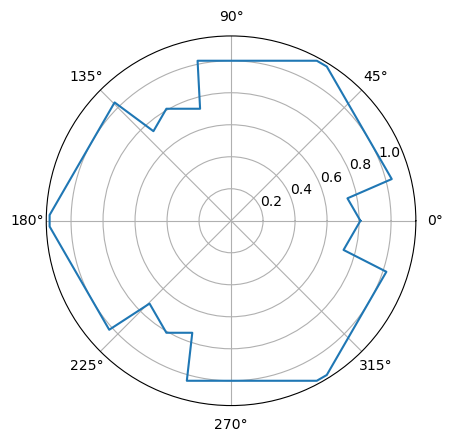

In [16]:
phi = np.linspace(0, 2 * np.pi, 100)
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(phi, hexagon_with_notch_starry_region(1)(phi))

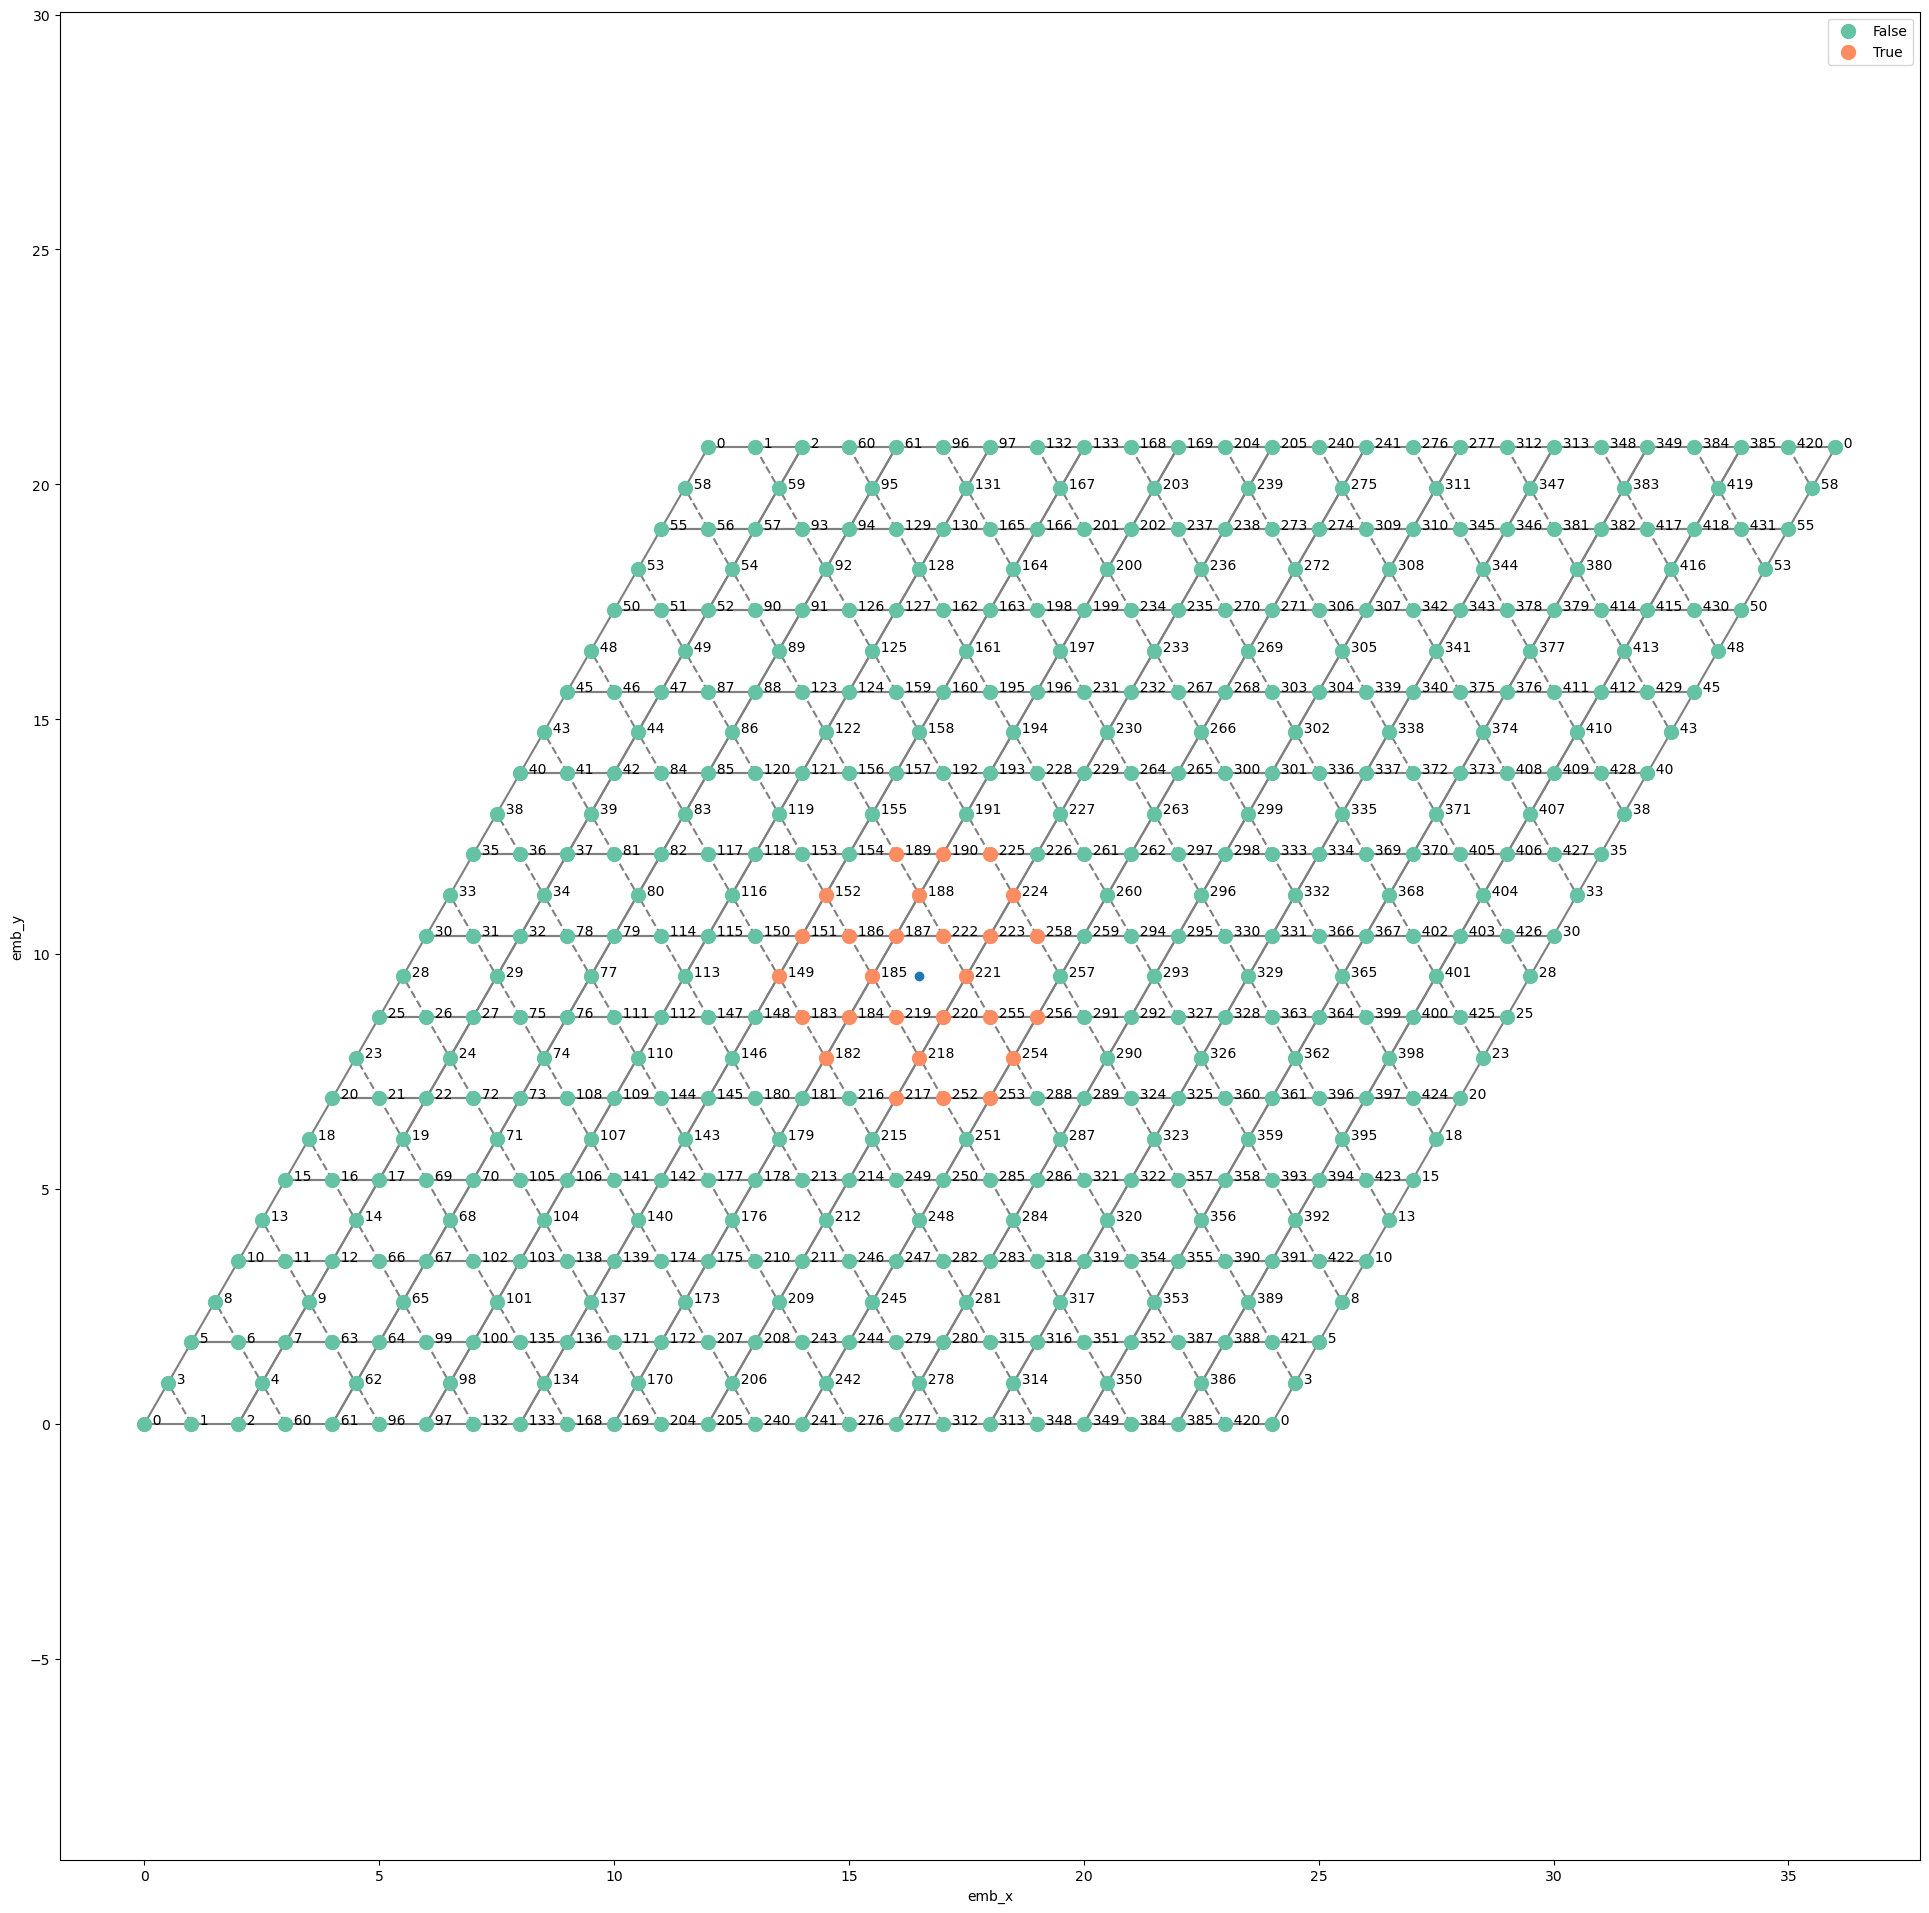

In [17]:
lat = KagomeLattice(12, 12)
u, v = lat.lattice_basis.T
hexagonal_center = lat.sites_df[['emb_x', 'emb_y']].mean().to_numpy() - u - v

fundamental_domain = lat.sites_df.query('is_canonical').apply(
    is_inside_starry_region_row,
    axis=1,
    args=(hexagonal_center, hexagon_with_notch_starry_region(np.linalg.norm(u + v) * 1.7)),
).to_numpy()

plt.figure(figsize=(24, 24))
lat.plot(spins=fundamental_domain, ax=plt.gca())

plt.plot(*hexagonal_center, 'o')

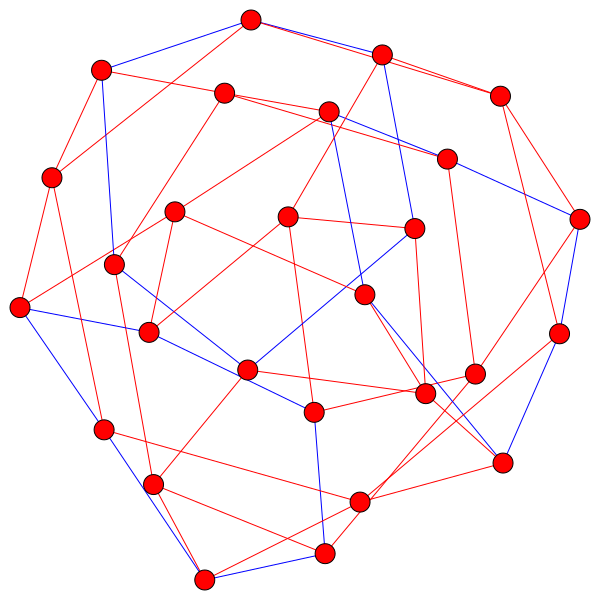

In [18]:
tx = Permutation(lat.get_translation("x"))
ty = Permutation(lat.get_translation("y"))
# righttop = tx**2 * ty**2
# rightbottom = tx**4 * ty ** (-2)
# bottom = tx ** (2) * ty ** (-4)

right = tx ** 3
topright = ty ** 3
bottomright = tx ** 3 * ty ** (-3)

fundamental_domain_elements = list(np.argwhere(fundamental_domain).flatten())
group_elements = list(
    itertools.chain(*[[right**i, topright**i, bottomright**i] for i in [1, -1]])
)

g = factor_lattice(
    lat.as_igraph(), group_elements=group_elements, fundamental_domain=fundamental_domain_elements
)

g.es["color"] = [{1: 'red', 2: 'blue'}[kind] for kind in g.es["kind"]]

igraph.plot(g)

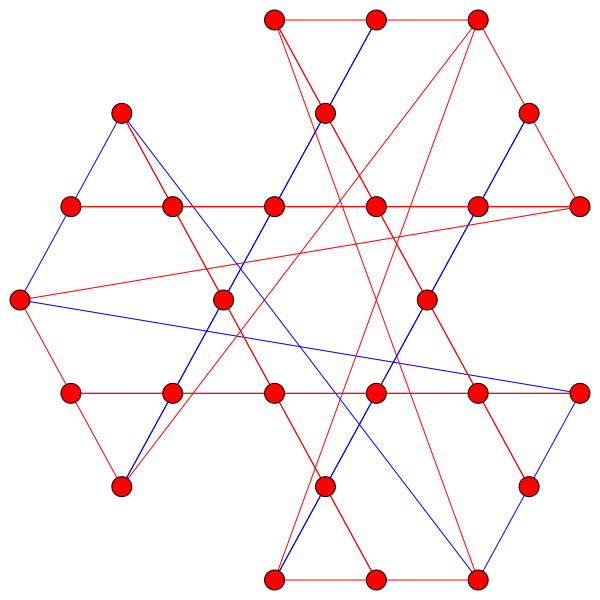

In [19]:
igraph.plot(
    g,
    layout=lat.sites_df.query("is_canonical")
    .set_index("num")
    .loc[[int(v["name"]) for v in g.vs]][["emb_x", "emb_y"]]
    .to_numpy(),
)

In [20]:
len(g.get_automorphisms_vf2())

216

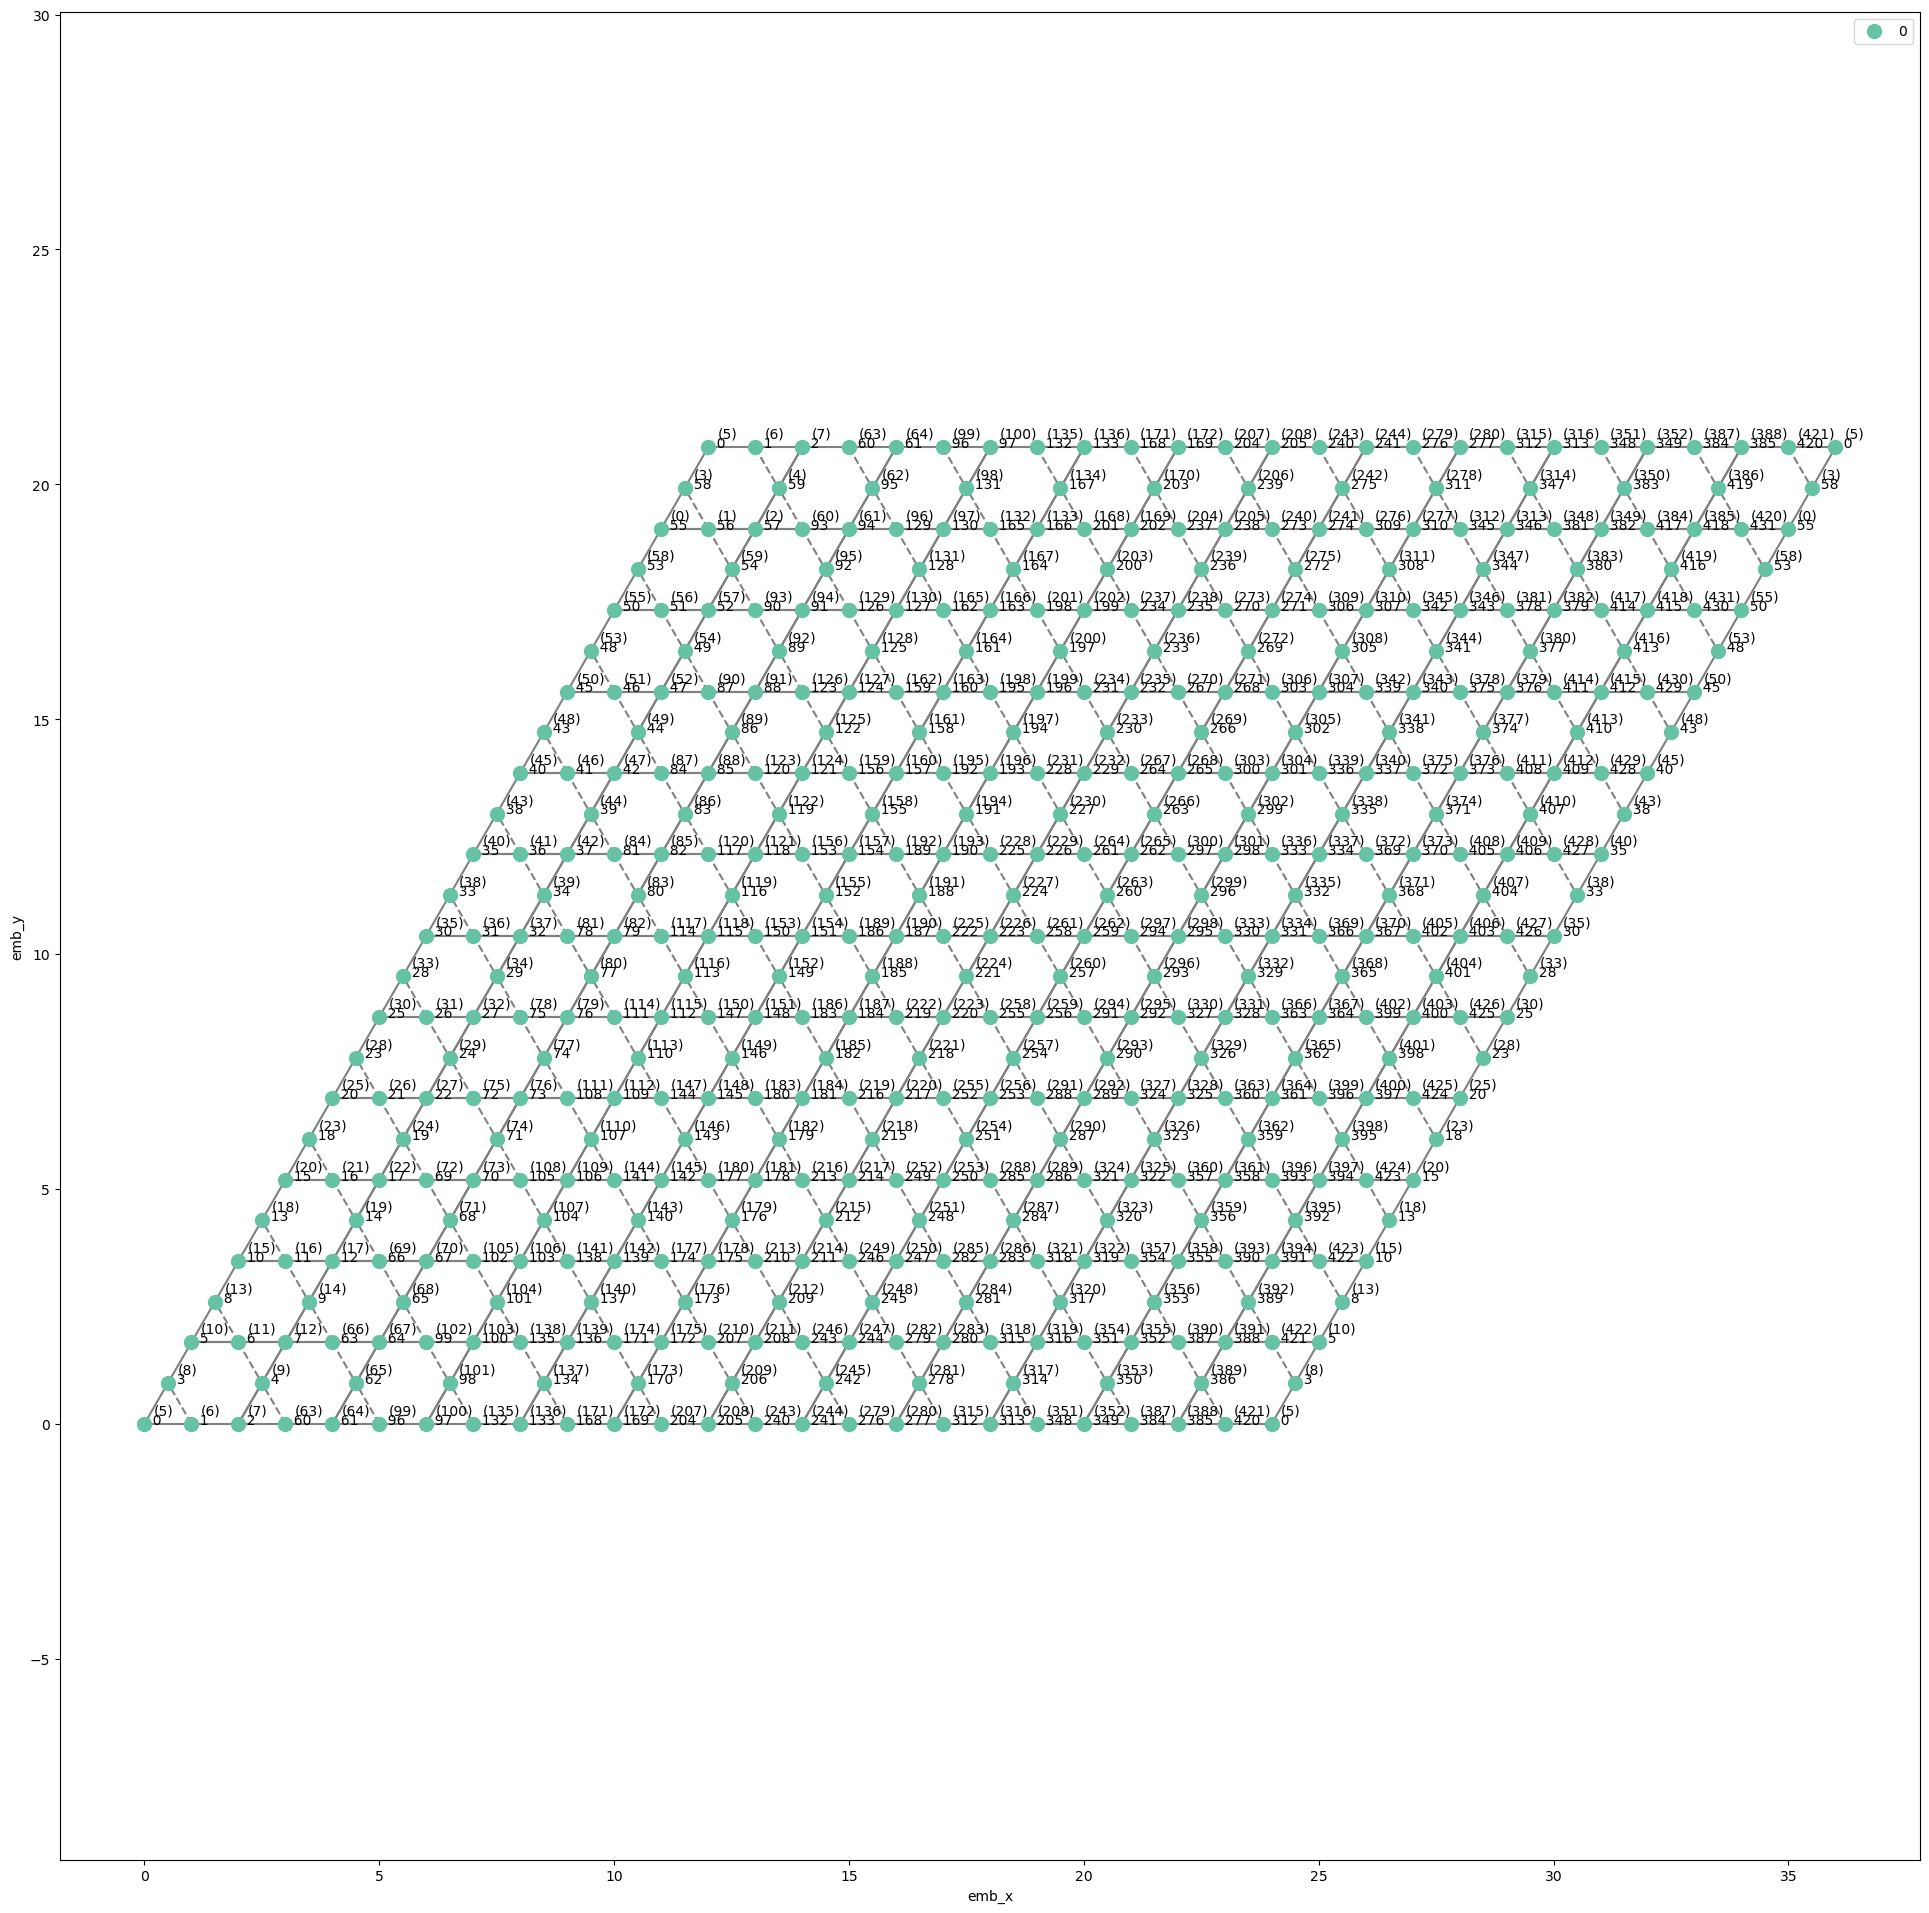

In [21]:
def vis_permutation(lat: SpinLattice, permutation: list[int], ax=ax):
    lat.plot(ax=ax)
    for _, row in lat.sites_df.iterrows():
        plt.text(row['emb_x'] + 0.2, row['emb_y'] + 0.2, "(" + str(permutation[row['num']]) + ")")
plt.figure(figsize=(24, 24))
vis_permutation(lat, ty.array_form, ax=plt.gca())

In [22]:
factor_lattice = FactorLattice(
    initial_lattice=lat,
    group_elements=group_elements,
    fundamental_domain=fundamental_domain_elements,
)

In [23]:
factor_lattice.edges = [(edge, 1) for edge, kind in factor_lattice.edges]

In [24]:
(lat.sites_df.query("is_canonical")
    .set_index("num")
    .loc[[int(v["name"]) for v in g.vs]][["emb_x", "emb_y"]]
    .to_numpy())

array([[13.5       ,  9.52627944],
       [14.        , 10.39230485],
       [14.5       , 11.25833025],
       [14.5       ,  7.79422863],
       [14.        ,  8.66025404],
       [15.        ,  8.66025404],
       [15.5       ,  9.52627944],
       [15.        , 10.39230485],
       [16.        , 10.39230485],
       [16.5       , 11.25833025],
       [16.        , 12.12435565],
       [17.        , 12.12435565],
       [16.        ,  6.92820323],
       [16.5       ,  7.79422863],
       [16.        ,  8.66025404],
       [17.        ,  8.66025404],
       [17.5       ,  9.52627944],
       [17.        , 10.39230485],
       [18.        , 10.39230485],
       [18.5       , 11.25833025],
       [18.        , 12.12435565],
       [17.        ,  6.92820323],
       [18.        ,  6.92820323],
       [18.5       ,  7.79422863],
       [18.        ,  8.66025404],
       [19.        ,  8.66025404],
       [19.        , 10.39230485]])

In [25]:
factor_lattice.sites_df

,num,ix,iy,is_canonical,emb_x,emb_y
0,0,8,11,True,13.5,9.526279
1,1,8,12,True,14.0,10.392305
2,2,8,13,True,14.5,11.258330
3,3,10,9,True,14.5,7.794229
4,4,9,10,True,14.0,8.660254
5,5,10,10,True,15.0,8.660254
6,6,10,11,True,15.5,9.526279
7,7,9,12,True,15.0,10.392305
8,8,10,12,True,16.0,10.392305
9,9,10,13,True,16.5,11.258330


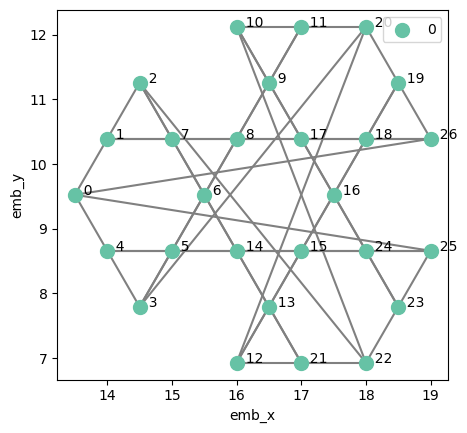

In [26]:
fig, ax = plt.subplots()
factor_lattice.plot(ax=ax)
# set aspect equal
ax.set_aspect('equal', adjustable='box')

In [36]:
import pandas as pd

In [37]:
pd.DataFrame(
    [(i, Permutation(g).order()) for i, g in enumerate(factor_lattice.get_automorphisms())],
    columns=["index", "order"],
).sort_values("order")

,index,order
0,0,1
37,37,2
186,186,2
45,45,2
48,48,2
...,...,...
187,187,12
105,105,12
38,38,12
214,214,12


In [41]:
system = HeisenbergJ1J2(lattice=factor_lattice, use_symmetries=True, spin_inversion=None, skip_symmetries_whitelist=True)
system.get_eigenstates(1)

2023-06-28 18:59:07.169 | WARNING  | heisenberg_hamiltonians:__init__:414 - Symmetries are not tested with KagomeLattice12x12_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-06-28 18:59:07.171 | DEBUG    | heisenberg_hamiltonians:__init__:446 - number_spins=27
2023-06-28 18:59:07.251 | DEBUG    | heisenberg_hamiltonians:__init__:456 - Symmetry group contains 216 elements
2023-06-28 18:59:07.252 | DEBUG    | heisenberg_hamiltonians:__init__:465 - Hilbert space dimension is 93610
2023-06-28 18:59:07.263 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:94 - Calculating eigenvalues / eigenstates
2023-06-28 19:00:02.753 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -46.4394192381


(array([-46.43941924]),
 array([[ 7.17005692e-08],
        [-3.07938086e-08],
        [ 1.51734008e-05],
        ...,
        [-3.05521486e-03],
        [-1.55399899e-04],
        [ 3.10799798e-04]]))

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

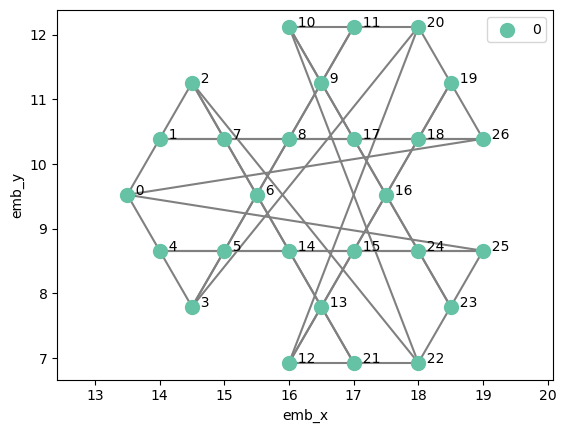

In [39]:
factor_lattice.plot()

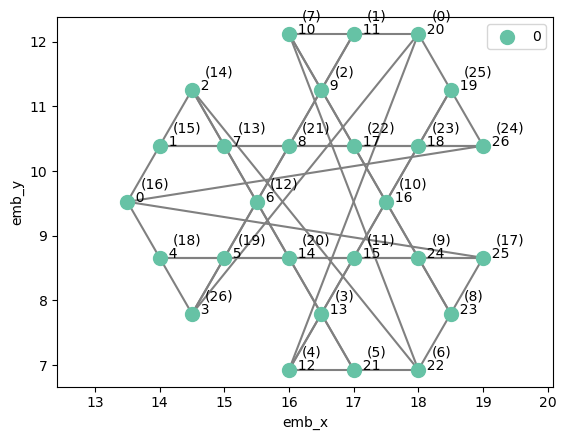

In [38]:
fig, ax = plt.subplots()
vis_permutation(factor_lattice, factor_lattice.get_automorphisms()[129], ax=ax)

In [34]:
system = HeisenbergJ1J2(
    lattice=factor_lattice,
    J2=1,
    use_symmetries=True,
    spin_inversion=None,
    skip_symmetries_whitelist=True,
)

2023-06-28 18:19:29.623 | WARNING  | heisenberg_hamiltonians:__init__:414 - Symmetries are not tested with KagomeLattice12x12_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-06-28 18:19:29.626 | DEBUG    | heisenberg_hamiltonians:__init__:446 - number_spins=36
2023-06-28 18:19:29.708 | DEBUG    | heisenberg_hamiltonians:__init__:456 - Symmetry group contains 144 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-06-28 18:21:38.074 | DEBUG    | heisenberg_hamiltonians:__init__:465 - Hilbert space dimension is 63044766
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
